In [ ]:
import scanpy as sc # specific to single cell RNA seq analysis ! 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import of all the libraries used afterwards. scanpy is essential 

In [ ]:
adata = sc.datasets.pbmc3k()
print(adata)
print(adata.var_names[:10]) # ten first genes

/Users/victorlalivedepinay/miniforge3/envs/scrnaseq/lib/python3.11/site-packages/scanpy/datasets/_utils.py:29: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if version.parse(ad.__version__).release >= (0, 8):


  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8',
       'AL627309.1', 'RP11-34P13.14', 'RP11-34P13.9', 'AP006222.2',
       'RP4-669L17.10'],
      dtype='object', name='index')


the data set PBMC 3k de 10X Genomics (2700 cells of peripheral blood) can be loaded directly from scanpy

In [10]:
print(adata.obs.head()) # see first cells 

print(adata.var.head()) # first genes 

print(f"Matrice : {adata.n_obs} cellules × {adata.n_vars} gènes") # matrix 

print(type(adata.X)) # type = sparse 

Empty DataFrame
Columns: []
Index: [AAACATACAACCAC-1, AAACATTGAGCTAC-1, AAACATTGATCAGC-1, AAACCGTGCTTCCG-1, AAACCGTGTATGCG-1]
                     gene_ids
index                        
MIR1302-10    ENSG00000243485
FAM138A       ENSG00000237613
OR4F5         ENSG00000186092
RP11-34P13.7  ENSG00000238009
RP11-34P13.8  ENSG00000239945
Matrice : 2700 cellules × 32738 gènes
<class 'scipy.sparse._csr.csr_matrix'>


In [11]:
df = pd.DataFrame(                 # we can convert it into panda dataframe, to visualize it
    adata.X.toarray(),
    index=adata.obs_names,      # barcode : line
    columns=adata.var_names     # genes : column
)
df.head()  # 5 first cell, every gene

df['CD4'].sort_values(ascending=False).head(20) # one specific gene for every cells

df.to_csv('pbmc3k_full_matrix.csv') # very heavy csv

this provide a csv of the data frame, just in order to control that it looks good (we won't use it)

I have to add here a way to filter data (double and empty droplet, ..)

/Users/victorlalivedepinay/miniforge3/envs/scrnaseq/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:198: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  version.parse(ad.__version__) < version.parse("0.9")


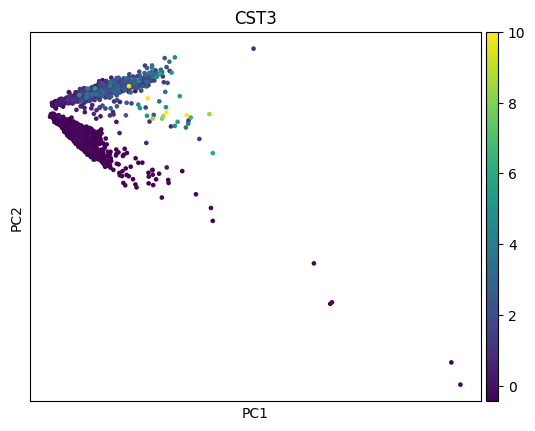

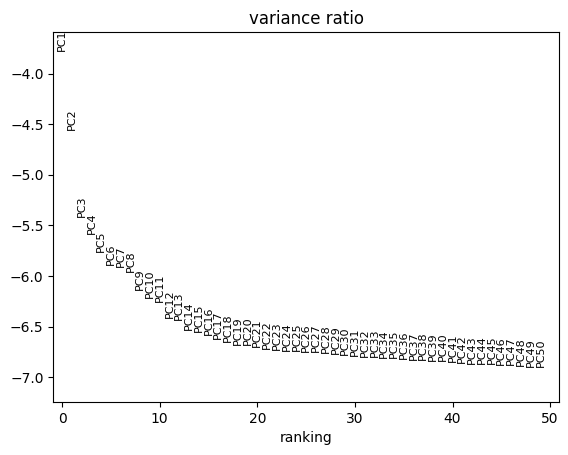

In [14]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack', n_comps=50)
sc.pl.pca(adata, color='CST3', save='_pca.png')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50, save='_elbow.png')  

Here, I make a PCA from the 50 principal components (90% of the variance explained)
also, I do an elbow plot, to see each principal component individually 

/Users/victorlalivedepinay/miniforge3/envs/scrnaseq/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:408: FutureWarning: The method obsm_keys is deprecated and will be removed in the future. Use obsm instead of obsm_keys. (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`)
  if "X_diffmap" in adata.obsm_keys():


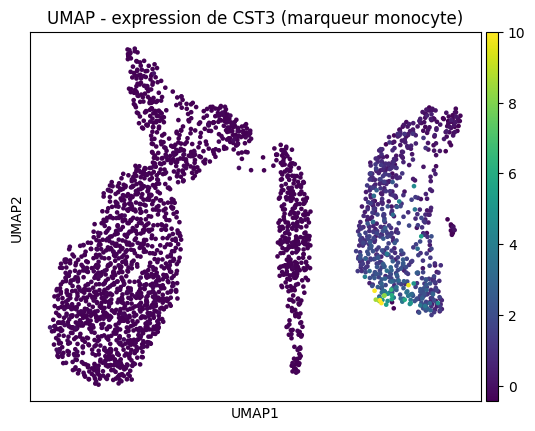

In [16]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=50) # we take 10 neighbours for each cell. PC = 50
sc.tl.umap(adata) # compute the umap values 

sc.pl.umap(adata, color='CST3',
    title='UMAP - expression de CST3 (marqueur monocyte)',
    save='_umap_cst3.png'
)

clusters here indicate different types of cells 
branches between the cluster could maybe indicate a state of differentiation (like monocytes -> macrophages)
(to review)

with PCs equal to 20 or even 5 : the shapes and clusters change 